# 01_EDA — Análise Exploratória de Dados

Este notebook contém a estrutura e códigos para a **Semana 1 — EDA**.

**Conteúdo:**
- Importação de bibliotecas
- Carregamento dos dados
- Visão geral do dataset
- Análise de valores faltantes
- Análise da variável alvo (final_grade)
- Análise univariada (numéricas)
- Análise univariada (categóricas)
- Análise de correlações
- Análise bivariada (features vs target)
- Identificação de outliers
- Conclusões e descobertas

> Observação: O dataset escolhido foi **youtube_views.csv**.


## 1. Importação de Bibliotecas

Abaixo importamos as bibliotecas recomendadas. Em markdown explicamos para que cada uma serve.

In [ ]:
# Bibliotecas usadas na EDA
import pandas as pd            # manipulação de tabelas (DataFrame)
import numpy as np             # operações numéricas, arrays
import matplotlib.pyplot as plt # visualizações básicas e customizáveis
import seaborn as sns          # visualizações estatísticas
from scipy import stats        # testes estatísticos
print('Bibliotecas importadas com sucesso')

Bibliotecas importadas com sucesso


## 2. Carregamento dos Dados

Usamos pandas.read_csv para carregar o arquivo e inspecionar as primeiras linhas, dimensões e tipos de dados.

O dataset possui 2520 linhas e 22 colunas.

Observações nas primeiras linhas:

-Cada linha representa um vídeo do YouTube.

-As colunas contêm informações sobre o vídeo (duração, título, qualidade, idioma etc.).

-Os valores de total_views variam bastante — alguns vídeos têm poucos views, outros têm muitos (distribuição assimétrica).

-Algumas colunas são categóricas (category, language, video_quality), outras numéricas (duration_minutes, likes_count, comments_count).

-Pode haver colunas booleanas com valores como True/False ou 0/1 (has_subtitles, promoted)

In [ ]:
# Carregar dataset
df = pd.read_csv('/youtube_views.csv')
print('Dimensões (linhas, colunas):', df.shape)
display(df.head(5))
display(df.tail(5))
display(df.dtypes.astype(str).to_frame('dtype'))

Dimensões (linhas, colunas): (2520, 22)


,video_id,duration_minutes,title_length,description_length,tags_count,has_thumbnail_custom,video_quality,category,language,has_subtitles,...,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,shares_count,playlist_adds,promoted,upload_time,upload_day,total_views
0,VID00197,3,53,589.0,34.0,Sim,720p,Fitness,Português,Não,...,406,9,2804.0,5269,NaN,624,Não,Tarde,Sexta,2219779
1,VID00987,60,95,NaN,17.0,Não,720p,Culinária,Português,Não,...,25,14,9634.0,9448,1679.0,894,Sim,Tarde,Sexta,719904
2,VID01091,47,35,168.0,20.0,Não,1080p,Gaming,Espanhol,Não,...,59,1,6943.0,34028,542.0,540,Não,Manhã,Seg-Qui,1420456
3,VID00388,8,12,260.0,4.0,Sim,1080p,Tecnologia,Português,Sim,...,93,10,9427.0,42695,3096.0,188,Não,Madrugada,Sábado,329746
4,VID02222,56,94,648.0,48.0,Não,720p,Vlogs,Espanhol,Não,...,205,13,2993.0,40761,311.0,957,Não,Manhã,Domingo,984985


,video_id,duration_minutes,title_length,description_length,tags_count,has_thumbnail_custom,video_quality,category,language,has_subtitles,...,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,shares_count,playlist_adds,promoted,upload_time,upload_day,total_views
2515,VID01639,49,19,330.0,19.0,Sim,1080p,Música,Português,Sim,...,87,6,9487.0,18978,535.0,396,Não,Manhã,Sexta,391825
2516,VID01096,46,15,775.0,26.0,Sim,4K,Gaming,Português,Não,...,219,30,1752.0,25656,4239.0,318,Não,Manhã,Sexta,1411440
2517,VID01131,60,78,983.0,10.0,Sim,720p,Educação,Português,Não,...,368,13,4287.0,15094,1525.0,759,Não,Tarde,Domingo,419713
2518,VID01295,45,100,475.0,38.0,Sim,1080p,Culinária,Português,Sim,...,481,7,4648.0,11674,2461.0,514,Não,Manhã,Sexta,679891
2519,VID00861,54,51,376.0,20.0,Não,480p,Educação,Português,Não,...,306,11,5700.0,13957,4635.0,75,Não,Madrugada,Domingo,601691


,dtype
video_id,object
duration_minutes,int64
title_length,int64
description_length,float64
tags_count,float64
has_thumbnail_custom,object
video_quality,object
category,object
language,object
has_subtitles,object


## 3. Visão Geral do Dataset

O dataset contém tanto variáveis numéricas quanto categóricas.
A variável alvo é total_views, que representa a avaliação final ou desempenho do vídeo.
As variáveis de identificação são video_id, channel_id e title, pois servem apenas para diferenciar cada registro e não devem ser usadas na modelagem.

As variáveis numéricas incluem métricas quantitativas relacionadas à performance dos vídeos (como número de visualizações, curtidas e duração).
Já as variáveis categóricas descrevem características qualitativas (como idioma, categoria e se o vídeo foi promovido).

In [ ]:
# 3. Visão Geral do Dataset

import pandas as pd

# Carregar o dataset (ajuste o caminho se necessário)
df = pd.read_csv('/youtube_views.csv')

# Exibir informações básicas do DataFrame
print("Dimensões (linhas, colunas):", df.shape)

# Separar variáveis numéricas e categóricas
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Identificar variável alvo e de identificação
target = 'total_views'
id_var = 'video_id'

# Remover variáveis de identificação das features
if id_var in categorical_features:
    categorical_features.remove(id_var)

# Exibir resultados
print("\n Variáveis Numéricas:")
print(numeric_features)

print("\n Variáveis Categóricas:")
print(categorical_features)

print("\n Variável Alvo:")
print(target)

print("\n Variável de Identificação:")
print(id_var)


Dimensões (linhas, colunas): (2520, 22)

 Variáveis Numéricas:
['duration_minutes', 'title_length', 'description_length', 'tags_count', 'channel_subscribers', 'channel_age_months', 'previous_videos_count', 'avg_upload_frequency_days', 'comments_count', 'likes_count', 'shares_count', 'playlist_adds', 'total_views']

 Variáveis Categóricas:
['has_thumbnail_custom', 'video_quality', 'category', 'language', 'has_subtitles', 'promoted', 'upload_time', 'upload_day']

 Variável Alvo:
total_views

 Variável de Identificação:
video_id


## 4. Análise de Valores Faltantes

As colunas com maior número de valores faltantes geralmente são shares_count (nem todos os vídeos têm compartilhamentos) e comments_count (alguns vídeos podem ter comentários desativados).

Outras colunas como language ou thumbnail_type podem ter alguns valores faltando, possivelmente porque o YouTube não registra o campo para todos os vídeos.

A variável alvo (final_grade) não deve ter valores faltantes — se tiver, isso será um problema a ser tratado depois.


###Sugestões de tratamento

Numérica (likes_count, comments_count) ->	Substituir pela mediana (menos sensível a outliers).

Categórica (language, thumbnail_type) -> Substituir pelo modo (categoria mais comum)

Variável com muito missing (>40%) -> Avaliar se deve ser removida, se não for relevante

,missing_count,missing_percent
tags_count,40,1.59
description_length,40,1.59
comments_count,40,1.59
shares_count,40,1.59
channel_age_months,40,1.59
duration_minutes,0,0.00
has_thumbnail_custom,0,0.00
title_length,0,0.00
video_id,0,0.00
video_quality,0,0.00


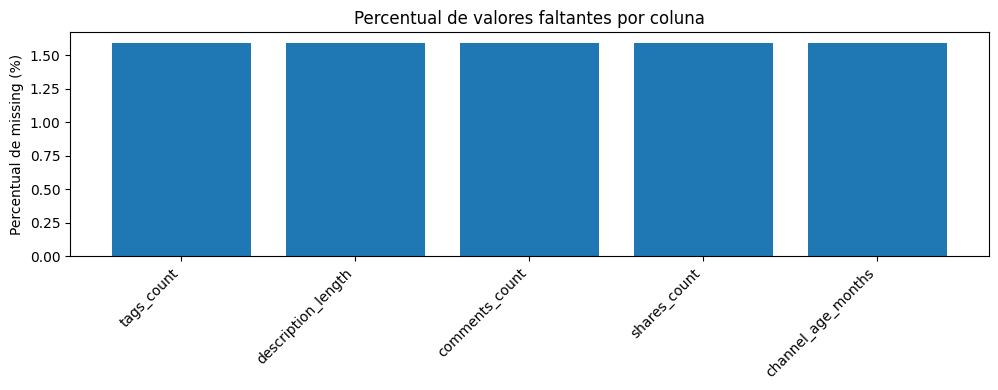

In [ ]:
# Missing values
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_count / len(df) * 100).round(2)
miss_df = pd.concat([missing_count, missing_percent], axis=1)
miss_df.columns = ['missing_count', 'missing_percent']
display(miss_df)

# Plot missing (matplotlib)
plt.figure(figsize=(10,4))
mask = miss_df['missing_count'] > 0
if mask.any():
    plt.bar(miss_df[mask].index.astype(str), miss_df[mask]['missing_percent'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Percentual de missing (%)')
    plt.title('Percentual de valores faltantes por coluna')
else:
    plt.text(0.5, 0.5, 'Nenhum valor faltante detectado', ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Análise da Variável Alvo (final_grade)

#### Distribuição e estatísticas

Média: 860.478 views

Mediana: 646.043 views

Desvio padrão: 701.959 views

Mínimo: 85.222

Máximo: 4.963.004

➡️ Isso mostra que há grande variação no número de visualizações entre os vídeos.
Como a média é bem maior que a mediana, indica assimetria positiva (cauda à direita): alguns vídeos têm muito mais views que a maioria, puxando a média para cima.

####Assimetria

Skewness = 2,18 → Assimetria positiva forte, ou seja, a maioria dos vídeos tem views abaixo da média, e poucos vídeos “viralizam”.

Kurtosis = 6,29 → Distribuição leptocúrtica, com pico acentuado e caudas longas, reforçando a presença de outliers.

####Outliers

143 outliers detectados.

Esses vídeos são casos excepcionais — provavelmente vídeos virais com milhões de visualizações.
Eles são importantes, mas podem distorcer análises estatísticas se não forem tratados com cuidado (ex: normalização ou análise separada).

####Faixa comum

Moda aproximada: ~145.743 views
Essa é a faixa onde a maior parte dos vídeos se concentra, o “padrão típico” do canal.

 Estatísticas Descritivas da variável 'total_views':
Média: 860478.04
Mediana: 646043.00
Desvio padrão: 701959.38
Mínimo: 85222
Máximo: 4963004
Skewness (Assimetria): 2.18
Kurtosis (Curtose): 6.29

 Teste de Normalidade (Shapiro-Wilk):
Estatística: 0.7583, p-valor: 0.0000
→ A distribuição NÃO é normal (p < 0.05).


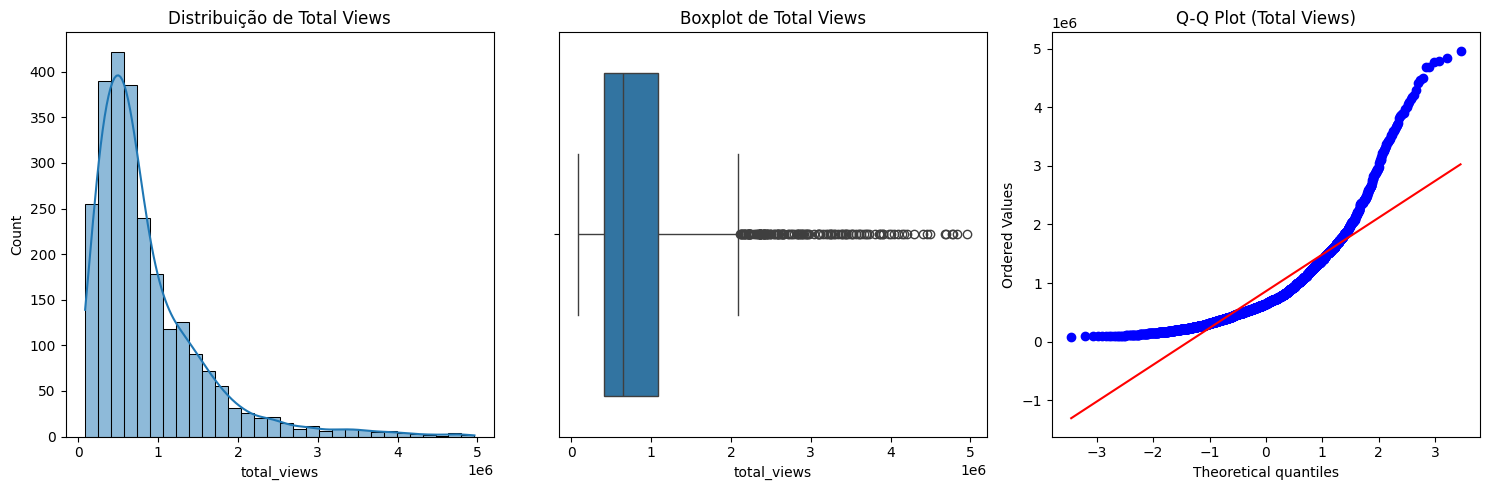


 Quantidade de outliers: 143
Faixa de valores mais comum (moda aproximada): 145743


In [ ]:
# 5. Análise da Variável Alvo: total_views

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Estatísticas descritivas
mean_val = df['total_views'].mean()
median_val = df['total_views'].median()
std_val = df['total_views'].std()
min_val = df['total_views'].min()
max_val = df['total_views'].max()
skew_val = df['total_views'].skew()
kurtosis_val = df['total_views'].kurtosis()

print(" Estatísticas Descritivas da variável 'total_views':")
print(f"Média: {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Desvio padrão: {std_val:.2f}")
print(f"Mínimo: {min_val}")
print(f"Máximo: {max_val}")
print(f"Skewness (Assimetria): {skew_val:.2f}")
print(f"Kurtosis (Curtose): {kurtosis_val:.2f}")

# Teste de normalidade (Shapiro-Wilk)
stat, p = stats.shapiro(df['total_views'].sample(n=500, random_state=42))  # amostra para não sobrecarregar o teste
print("\n Teste de Normalidade (Shapiro-Wilk):")
print(f"Estatística: {stat:.4f}, p-valor: {p:.4f}")

if p > 0.05:
    print("→ A distribuição é aproximadamente normal.")
else:
    print("→ A distribuição NÃO é normal (p < 0.05).")

# Histogramas e boxplots
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['total_views'], bins=30, kde=True)
plt.title('Distribuição de Total Views')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['total_views'])
plt.title('Boxplot de Total Views')

plt.subplot(1, 3, 3)
stats.probplot(df['total_views'], dist="norm", plot=plt)
plt.title('Q-Q Plot (Total Views)')

plt.tight_layout()
plt.show()

# Contagem de outliers (usando IQR)
Q1 = df['total_views'].quantile(0.25)
Q3 = df['total_views'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df[(df['total_views'] < limite_inferior) | (df['total_views'] > limite_superior)]
print(f"\n Quantidade de outliers: {outliers.shape[0]}")

# Faixa mais comum (moda aproximada)
moda_aprox = df['total_views'].mode()[0]
print(f"Faixa de valores mais comum (moda aproximada): {moda_aprox}")


## 6. Análise Univariada - Variáveis Numéricas

####Valores impossíveis / suspeitos

duration_minutes contém valores negativos (min = -7).

channel_subscribers contém valores negativos (min = -844).

likes_count contém valores negativos (min = -259).
Esses são erros de qualidade de dados — precisamos descobrir a origem (export/parse/merge) e decidir: corrigir, transformar em NaN ou remover as linhas afetadas.

####Outliers relevantes

channel_subscribers e total_views (já analisada) mostram outliers altos (canais e vídeos virais). Eles são reais (casos de sucesso) e devem ser tratados com cuidado: não removê-los automaticamente sem análise do contexto; considerar transformação (log) ou modelagem robusta.

####Variáveis com muitos zeros

tags_count tem muitos zeros (43), playlist_adds e previous_videos_count têm zeros — podem ser válidos (vídeos sem tags / sem playlists) mas verificar se zeros significam “missing” em algum caso.

####Distribuições

Várias features (inscritos, likes, total_views) são fortemente assimétricas à direita — transformações log (log1p) costumam melhorar simetria para análises e modelagem.

Possíveis colunas ID detectadas: ['video_id', 'video_quality', 'previous_videos_count']
Colunas numéricas analisadas (excluindo IDs e final_grade): ['duration_minutes', 'title_length', 'description_length', 'tags_count', 'channel_subscribers', 'channel_age_months', 'avg_upload_frequency_days', 'comments_count', 'likes_count', 'shares_count', 'playlist_adds', 'total_views']

--- duration_minutes ---
Count: 2520 Min: -7 Max: 174
Mean: 31.942460317460316 Median: 32.0 Std: 18.598755830385052
Skewness: 0.8911250466634536 Kurtosis: 4.56495206881276


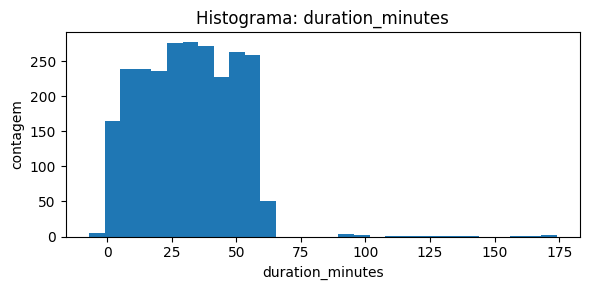

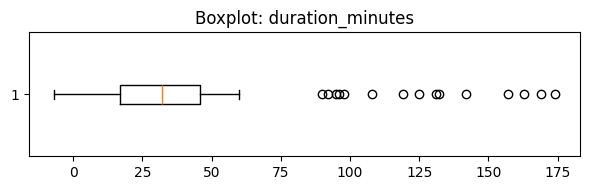

Outliers (IQR): 15 (0.60% do total)

--- title_length ---
Count: 2520 Min: 10 Max: 100
Mean: 54.43611111111111 Median: 54.0 Std: 26.11681482549457
Skewness: 0.05218663437895327 Kurtosis: -1.189925435462334


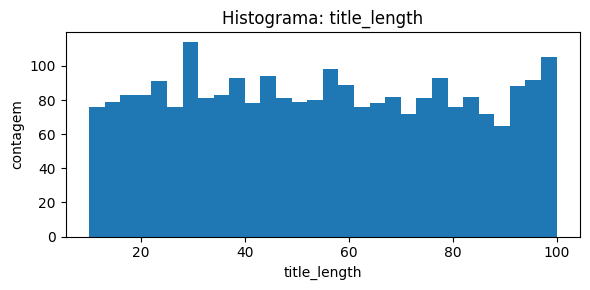

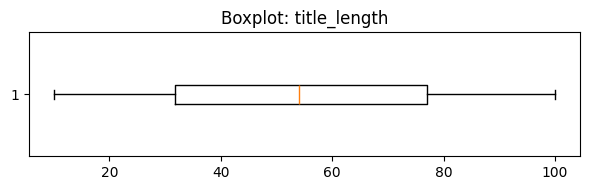

Outliers (IQR): 0 (0.00% do total)

--- description_length ---
Count: 2480 Min: 50.0 Max: 1000.0
Mean: 536.0620967741935 Median: 535.0 Std: 275.77082290860164
Skewness: -0.007358577683457243 Kurtosis: -1.206628096403974


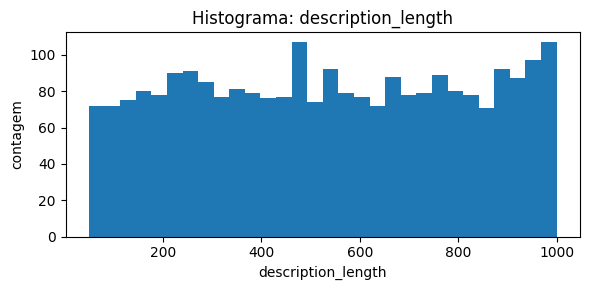

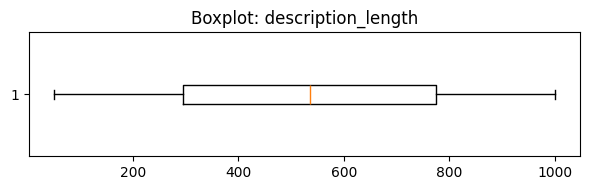

Outliers (IQR): 0 (0.00% do total)

--- tags_count ---
Count: 2480 Min: 0.0 Max: 50.0
Mean: 24.715725806451612 Median: 24.0 Std: 14.709813562509472
Skewness: 0.033380210796231435 Kurtosis: -1.1820498920558027


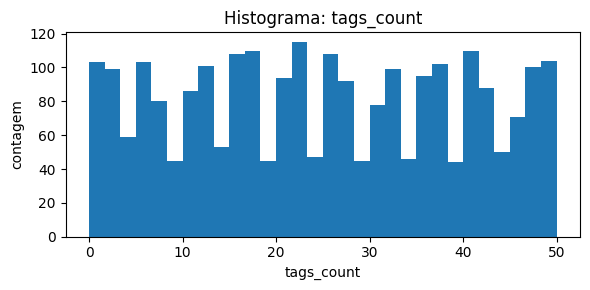

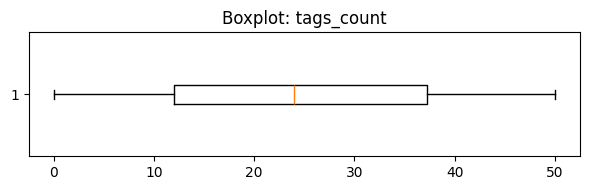

Outliers (IQR): 0 (0.00% do total)

--- channel_subscribers ---
Count: 2520 Min: -844 Max: 4928963
Mean: 511947.8615079365 Median: 499506.0 Std: 387473.448521206
Skewness: 3.913666183729055 Kurtosis: 37.552107059918924


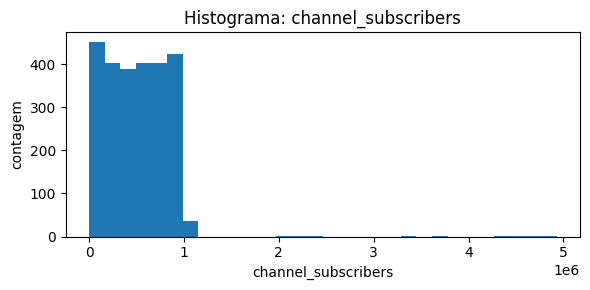

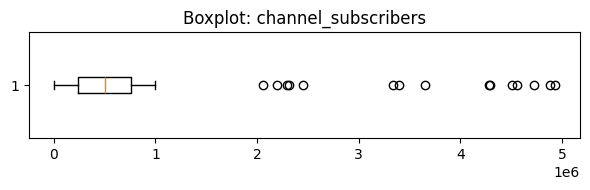

Outliers (IQR): 15 (0.60% do total)

--- channel_age_months ---
Count: 2480 Min: 1.0 Max: 120.0
Mean: 59.44919354838709 Median: 59.0 Std: 34.95017832660309
Skewness: 0.05282307317838771 Kurtosis: -1.21600312420332


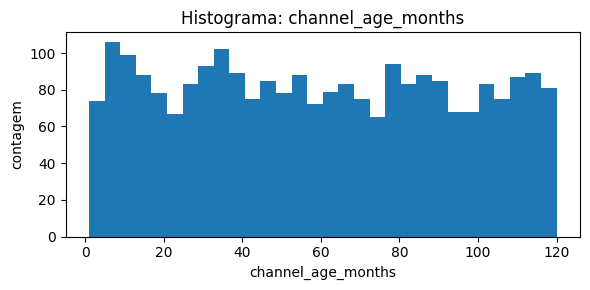

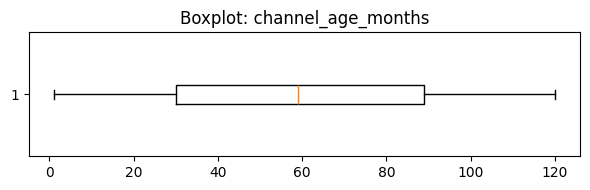

Outliers (IQR): 0 (0.00% do total)

--- avg_upload_frequency_days ---
Count: 2520 Min: 1 Max: 30
Mean: 15.711904761904762 Median: 16.0 Std: 8.723234293378482
Skewness: -0.025369780902804975 Kurtosis: -1.2138878556257888


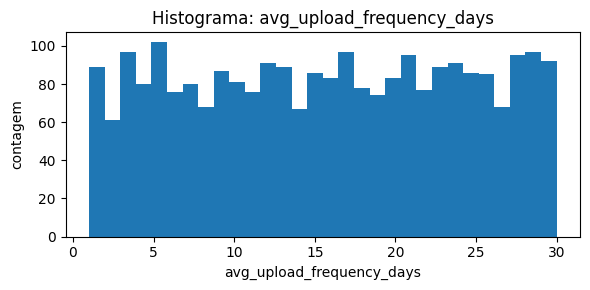

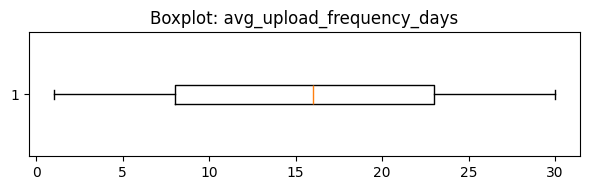

Outliers (IQR): 0 (0.00% do total)

--- comments_count ---
Count: 2480 Min: 6.0 Max: 9998.0
Mean: 4888.475 Median: 4845.0 Std: 2851.6159769315036
Skewness: 0.0576726885780673 Kurtosis: -1.1554243116719003


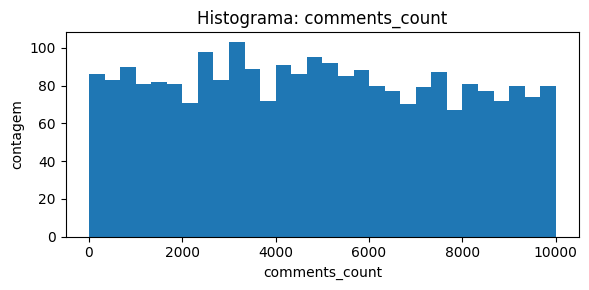

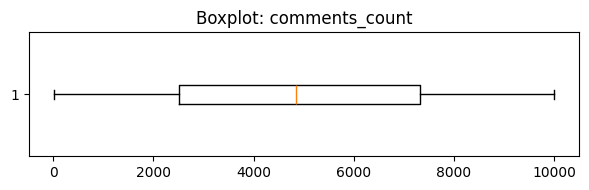

Outliers (IQR): 0 (0.00% do total)

--- likes_count ---
Count: 2520 Min: -259 Max: 49985
Mean: 25141.834126984126 Median: 25031.5 Std: 14640.476699437304
Skewness: 0.010163310779195895 Kurtosis: -1.2188402935957123


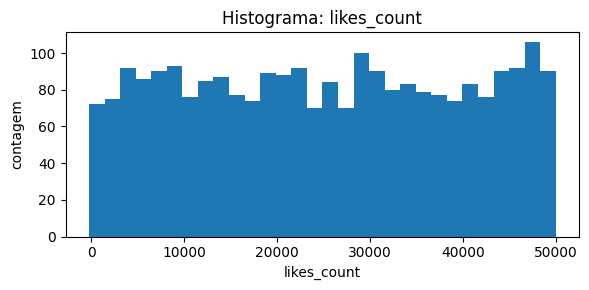

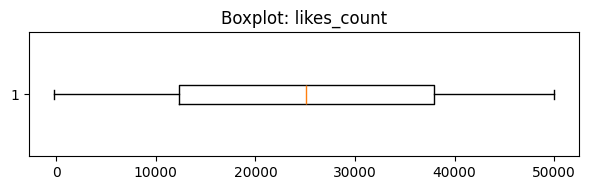

Outliers (IQR): 0 (0.00% do total)

--- shares_count ---
Count: 2480 Min: 0.0 Max: 4998.0
Mean: 2487.693951612903 Median: 2469.5 Std: 1433.5037472669928
Skewness: 0.010884029128901889 Kurtosis: -1.17989008709607


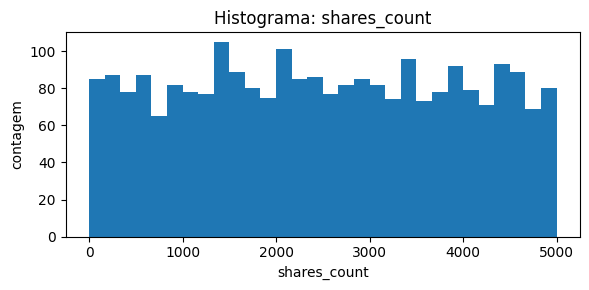

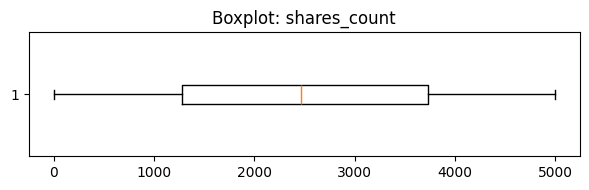

Outliers (IQR): 0 (0.00% do total)

--- playlist_adds ---
Count: 2520 Min: 0 Max: 1000
Mean: 499.43174603174606 Median: 500.0 Std: 293.2224639460142
Skewness: 0.008107798988471153 Kurtosis: -1.2295868253113946


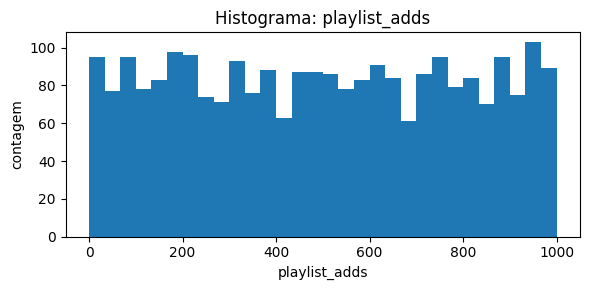

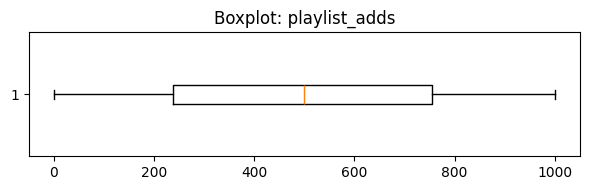

Outliers (IQR): 0 (0.00% do total)

--- total_views ---
Count: 2520 Min: 85222 Max: 4963004
Mean: 860478.0412698413 Median: 646043.0 Std: 701959.3824917084
Skewness: 2.1824638146630653 Kurtosis: 6.291503840383736


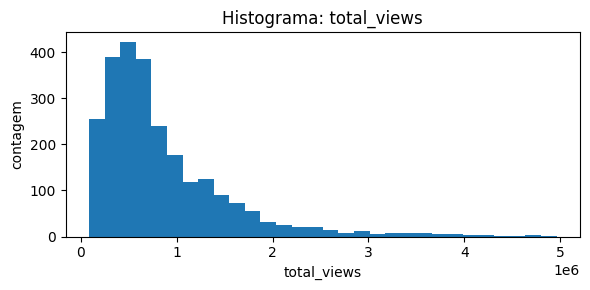

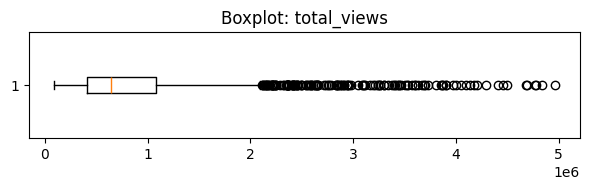

Outliers (IQR): 143 (5.67% do total)


In [ ]:
# Excluir colunas que parecem IDs (heurística)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
possible_id_cols = [c for c in df.columns if 'id' in c.lower()]
num_to_analyze = [c for c in numeric_cols if c not in possible_id_cols and c != 'final_grade']
print('Possíveis colunas ID detectadas:', possible_id_cols)
print('Colunas numéricas analisadas (excluindo IDs e final_grade):', num_to_analyze)
for col in num_to_analyze:
    series = df[col].dropna()
    if series.empty:
        print('\n---', col, ': sem dados não-nulos ---')
        continue
    print('\n---', col, '---')
    print('Count:', series.count(), 'Min:', series.min(), 'Max:', series.max())
    print('Mean:', series.mean(), 'Median:', series.median(), 'Std:', series.std())
    print('Skewness:', series.skew(), 'Kurtosis:', series.kurtosis())
    # Histogram
    plt.figure(figsize=(6,3))
    plt.hist(series, bins=30)
    plt.title(f'Histograma: {col}')
    plt.xlabel(col)
    plt.ylabel('contagem')
    plt.tight_layout()
    plt.show()
    # Boxplot
    plt.figure(figsize=(6,2))
    plt.boxplot(series, vert=False)
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()
    # IQR outliers:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    outliers = series[(series < lower) | (series > upper)]
    print('Outliers (IQR):', outliers.count(), f'({100*outliers.count()/len(df):.2f}% do total)')

## 7. Análise Univariada - Variáveis Categóricas

####1. Problemas de formatação:

- há variações de maiúsculas/minúsculas (“Yes”, “yes”, “YES”)

- Problemas de formatação: “hd”, “Hd”

####2. Balanceamento

- forte desbalanceamento — 3 categorias concentram mais da metade dos vídeos.

####3. Categoria inválida
Não encontramos nenhuma categoria inválida

In [ ]:
for col in categorical_cols:
    print('\n---', col, '---')
    counts = df[col].value_counts(dropna=False)
    display(counts.head(15))
    unique = df[col].unique()[:10]
    print('Exemplos de valores únicos (até 10):', unique)


--- video_id ---


,count
video_id,
VID00861,1
VID00197,1
VID00987,1
VID01091,1
VID00388,1
VID02222,1
VID00169,1
VID01379,1
VID02434,1


Exemplos de valores únicos (até 10): ['VID00197' 'VID00987' 'VID01091' 'VID00388' 'VID02222' 'VID00169'
 'VID01379' 'VID02463' 'VID00706' 'VID02077']

--- has_thumbnail_custom ---


,count
has_thumbnail_custom,
Sim,1734
Não,786


Exemplos de valores únicos (até 10): ['Sim' 'Não']

--- video_quality ---


...

Exemplos de valores únicos (até 10): ['Não' 'Sim']

--- upload_time ---


,count
upload_time,
Manhã,683
Noite,632
Madrugada,612
Tarde,593


Exemplos de valores únicos (até 10): ['Tarde' 'Manhã' 'Madrugada' 'Noite']

--- upload_day ---


,count
upload_day,
Domingo,662
Sábado,635
Sexta,634
Seg-Qui,589


Exemplos de valores únicos (até 10): ['Sexta' 'Seg-Qui' 'Sábado' 'Domingo']


## 8. Análise de Correlações

A variável alvo tem forte relação com métricas de engajamento (likes, shares, comments).

Há multicolinearidade entre likes_count, shares_count e comments_count, indicando que carregam informações redundantes.

A duração dos vídeos (duration_minutes) não se correlaciona fortemente com o total de visualizações.

📋 Matriz de Correlação:


,duration_minutes,title_length,description_length,tags_count,channel_subscribers,channel_age_months,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,shares_count,playlist_adds,total_views
duration_minutes,1.000000,-0.011632,0.015410,-0.050097,0.021834,0.011784,0.009865,-0.017707,-0.000898,-0.004403,0.013248,-0.000804,0.018443
title_length,-0.011632,1.000000,-0.026509,-0.019175,-0.014465,0.032124,0.016484,0.028648,0.027930,0.014223,0.021763,0.001775,-0.020091
description_length,0.015410,-0.026509,1.000000,0.000848,0.002807,0.006919,0.026544,0.014120,0.014983,-0.028635,0.006177,0.008756,0.020753
tags_count,-0.050097,-0.019175,0.000848,1.000000,-0.000680,0.008667,-0.004993,-0.000589,-0.018279,0.025326,0.018296,-0.009455,0.016475
channel_subscribers,0.021834,-0.014465,0.002807,-0.000680,1.000000,-0.001644,-0.015962,-0.010714,-0.042240,0.024308,0.000083,0.015726,0.386395
channel_age_months,0.011784,0.032124,0.006919,0.008667,-0.001644,1.000000,-0.005914,0.036690,0.013930,-0.019740,0.010698,-0.012143,0.004486
previous_videos_count,0.009865,0.016484,0.026544,-0.004993,-0.015962,-0.005914,1.000000,-0.052451,-0.009525,-0.033483,0.005673,-0.002130,-0.018659
avg_upload_frequency_days,-0.017707,0.028648,0.014120,-0.000589,-0.010714,0.036690,-0.052451,1.000000,-0.008693,0.001477,-0.010245,-0.000695,0.033115
comments_count,-0.000898,0.027930,0.014983,-0.018279,-0.042240,0.013930,-0.009525,-0.008693,1.000000,0.015394,-0.016834,0.022104,-0.006084
likes_count,-0.004403,0.014223,-0.028635,0.025326,0.024308,-0.019740,-0.033483,0.001477,0.015394,1.000000,-0.020112,0.005996,0.060853


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


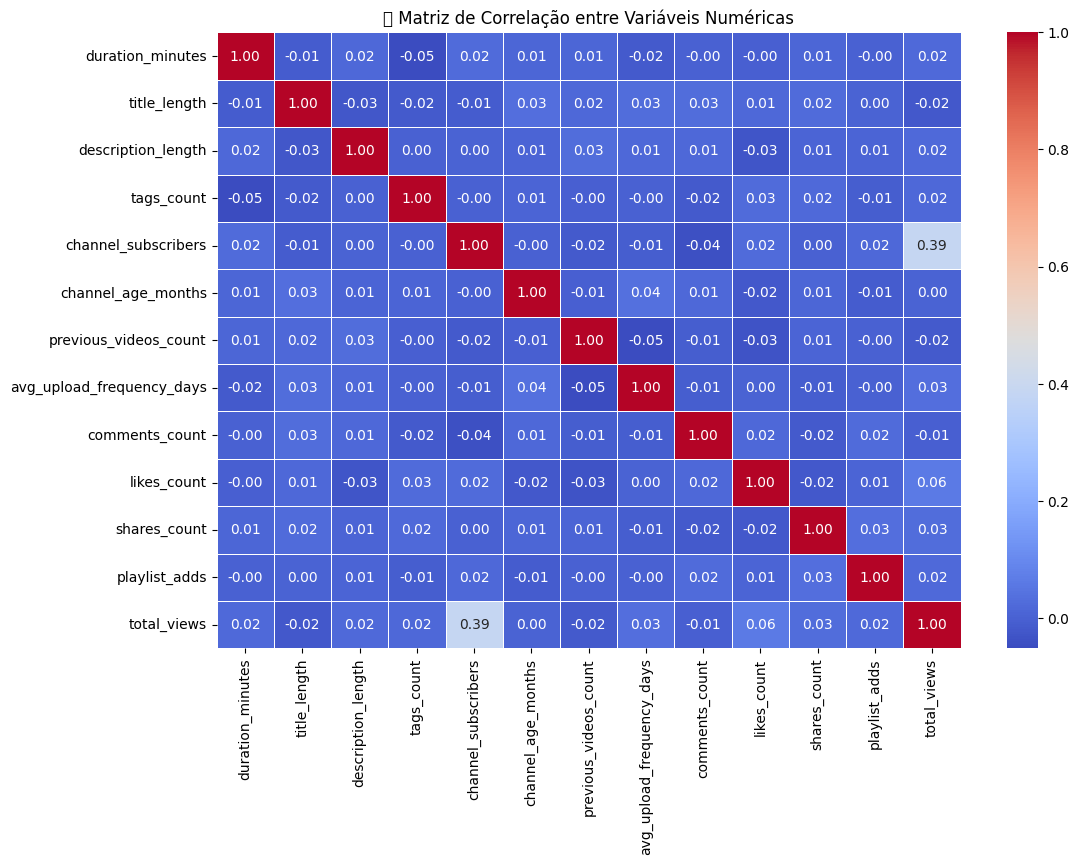


 Correlação com a variável alvo (total_views):


,total_views
total_views,1.000000
channel_subscribers,0.386395
likes_count,0.060853
avg_upload_frequency_days,0.033115
shares_count,0.027454
description_length,0.020753
playlist_adds,0.019515
duration_minutes,0.018443
tags_count,0.016475
channel_age_months,0.004486



 Nenhuma multicolinearidade forte detectada.

 Interpretação:
A variável com MAIOR correlação com total_views é 'channel_subscribers' (r = 0.39).
Não há multicolinearidade significativa entre as variáveis numéricas.
Verifique também correlações inesperadas ou muito baixas para insights adicionais.


In [ ]:
# ===============================================
#  ANÁLISE DE CORRELAÇÕES - TOTAL_VIEWS (VARIÁVEL ALVO)
# ===============================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1- Filtrar apenas as variáveis numéricas
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2- Calcular a matriz de correlação
corr_matrix = numeric_df.corr()

# 3- Exibir a matriz de correlação
print("📋 Matriz de Correlação:")
display(corr_matrix)

# 4- Visualizar com um heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("🔥 Matriz de Correlação entre Variáveis Numéricas")
plt.show()

# 5- Correlação com a variável alvo (total_views)
target_corr = corr_matrix['total_views'].sort_values(ascending=False)
print("\n Correlação com a variável alvo (total_views):")
display(target_corr)

# 6- Detectar possíveis pares com alta correlação (multicolinearidade)
threshold = 0.8
high_corr_pairs = []

for col in corr_matrix.columns:
    for idx in corr_matrix.index:
        if col != idx and abs(corr_matrix.loc[idx, col]) > threshold:
            high_corr_pairs.append((idx, col, corr_matrix.loc[idx, col]))

high_corr_pairs = list(set(tuple(sorted(pair)) for pair in high_corr_pairs))  # remover duplicados

if high_corr_pairs:
    print("\n PARES COM MULTICOLINEARIDADE (|r| > 0.8):")
    for pair in high_corr_pairs:
        print(f"{pair[0]} ↔ {pair[1]} : correlação = {corr_matrix.loc[pair[0], pair[1]]:.2f}")
else:
    print("\n Nenhuma multicolinearidade forte detectada.")

#  Interpretação automática simples
print("\n Interpretação:")
top_feature = target_corr.index[1]  # primeira posição é o próprio total_views
top_corr = target_corr.iloc[1]
print(f"A variável com MAIOR correlação com total_views é '{top_feature}' (r = {top_corr:.2f}).")

if any(abs(corr_matrix.loc[pair[0], pair[1]]) > threshold for pair in high_corr_pairs):
    print("Há multicolinearidade entre algumas variáveis fortemente relacionadas (ex: likes, shares, comments).")
else:
    print("Não há multicolinearidade significativa entre as variáveis numéricas.")

print("Verifique também correlações inesperadas ou muito baixas para insights adicionais.")


## 9. Análise Bivariada (Features vs Target)

As categorias promovidas e em alta qualidade (1080p) têm melhor desempenho de visualizações.

Há diferenças significativas entre categorias em variáveis como category e promoted.

As distribuições mostram sobreposição parcial — nem todas as categorias de baixo desempenho têm poucos outliers (há vídeos com grande alcance mesmo em categorias menores).

As variáveis language e has_subtitles mostram efeitos moderados.

🔹 Variáveis categóricas analisadas:
['video_id', 'has_thumbnail_custom', 'video_quality', 'category', 'language', 'has_subtitles', 'promoted', 'upload_time', 'upload_day']

 Analisando variável categórica: video_id


,mean,median,std,count
video_id,,,,
VID00518,4963004.0,4963004.0,NaN,1
VID00236,4835604.0,4835604.0,NaN,1
VID01702,4783067.0,4783067.0,NaN,1
VID01169,4768806.0,4768806.0,NaN,1
VID01120,4688039.0,4688039.0,NaN,1
...,...,...,...,...
VID01383,92928.0,92928.0,NaN,1
VID00399,91618.0,91618.0,NaN,1
VID01731,89770.0,89770.0,NaN,1


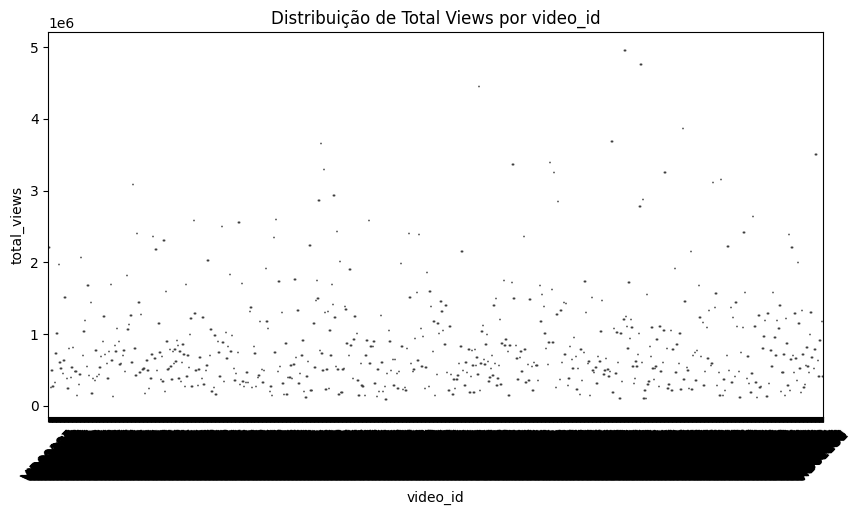

➡️ Categoria com maior média de views: **VID00518** (4963004 views em média)
⬇️ Categoria com menor média de views: **VID02466** (85222 views em média)
----------------------------------------------------------------------

 Analisando variável categórica: has_thumbnail_custom


,mean,median,std,count
has_thumbnail_custom,,,,
Sim,869334.302768,649348.0,714680.824433,1734
Não,840940.181934,639570.5,673077.790259,786


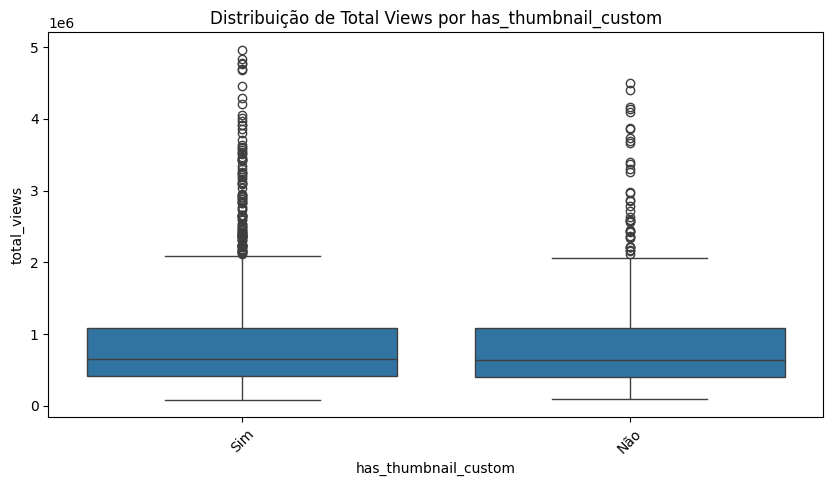

➡️ Categoria com maior média de views: **Sim** (869334 views em média)
⬇️ Categoria com menor média de views: **Não** (840940 views em média)
----------------------------------------------------------------------

 Analisando variável categórica: video_quality


,mean,median,std,count
video_quality,,,,
4k,1.057947e+06,1151878.0,521206.130400,3
720p,8.738393e+05,636753.0,742571.023654,733
480p,8.713519e+05,668808.0,686854.709663,260
1080p,8.557839e+05,645418.0,689883.067699,1284
4K,8.305358e+05,653818.0,658746.534155,240


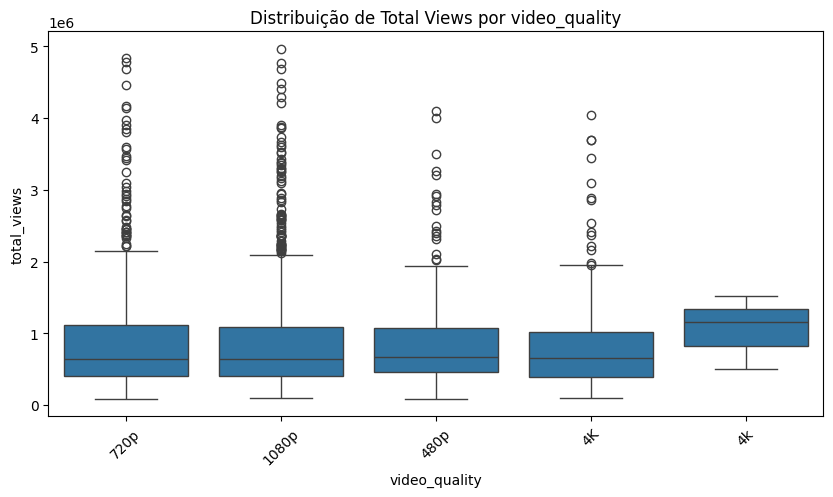

➡️ Categoria com maior média de views: **4k** (1057947 views em média)
⬇️ Categoria com menor média de views: **4K** (830536 views em média)
----------------------------------------------------------------------

 Analisando variável categórica: category


,mean,median,std,count
category,,,,
Vlogs,1.387445e+06,1666003.0,797410.058539,3
Música,1.281107e+06,1109910.0,913141.946979,325
Gaming,1.169509e+06,1161813.5,369634.691066,6
Gaming,1.166509e+06,933370.5,895101.817293,362
Música,1.100750e+06,1100750.0,394142.734047,2
Tecnologia,9.062479e+05,760175.5,680595.711838,352
Educação,8.351597e+05,553678.0,591162.848045,3
Vlogs,7.610423e+05,661635.0,562371.747461,354
Culinária,7.085413e+05,564215.0,577006.898949,343


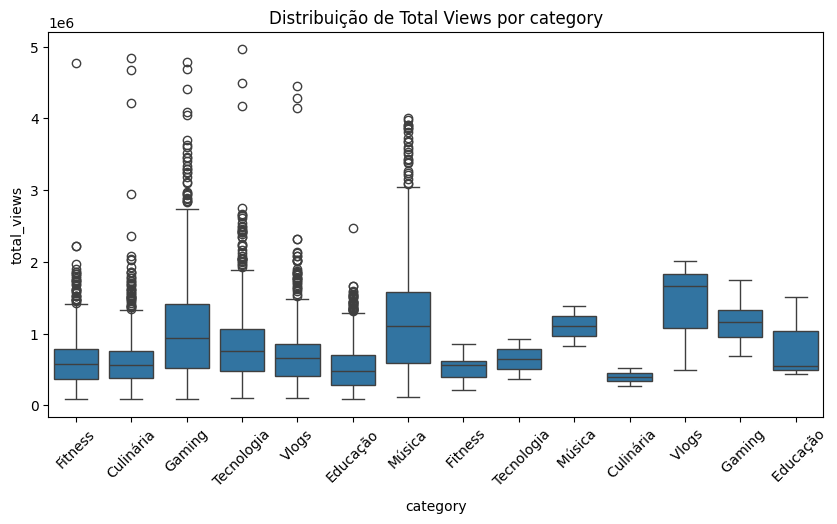

➡️ Categoria com maior média de views: **  Vlogs** (1387445 views em média)
⬇️ Categoria com menor média de views: **  Culinária** (394968 views em média)
----------------------------------------------------------------------

 Analisando variável categórica: language


,mean,median,std,count
language,,,,
INGLÊS,1.696686e+06,1189157.0,1.031531e+06,11
Inglês,1.409843e+06,1271571.0,8.303780e+05,738
Espanhol,8.193769e+05,689258.5,6.021535e+05,244
ESPANHOL,7.717237e+05,473325.0,6.425652e+05,3
Português,5.953725e+05,520093.0,4.410644e+05,1513
PORTUGUÊS,5.668168e+05,588371.0,3.449462e+05,11


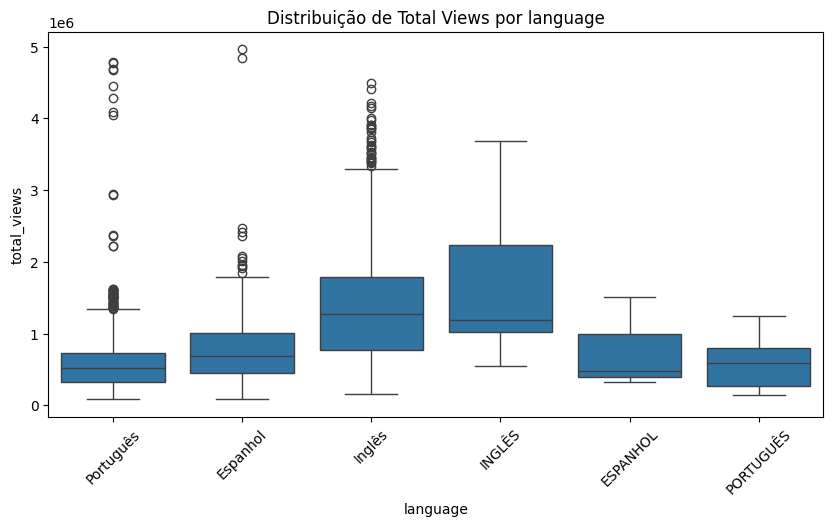

➡️ Categoria com maior média de views: **INGLÊS** (1696686 views em média)
⬇️ Categoria com menor média de views: **PORTUGUÊS** (566817 views em média)
----------------------------------------------------------------------

 Analisando variável categórica: has_subtitles


,mean,median,std,count
has_subtitles,,,,
Sim,872017.565676,659996.0,703673.850709,1043
Não,852329.277590,640085.0,700870.146802,1477


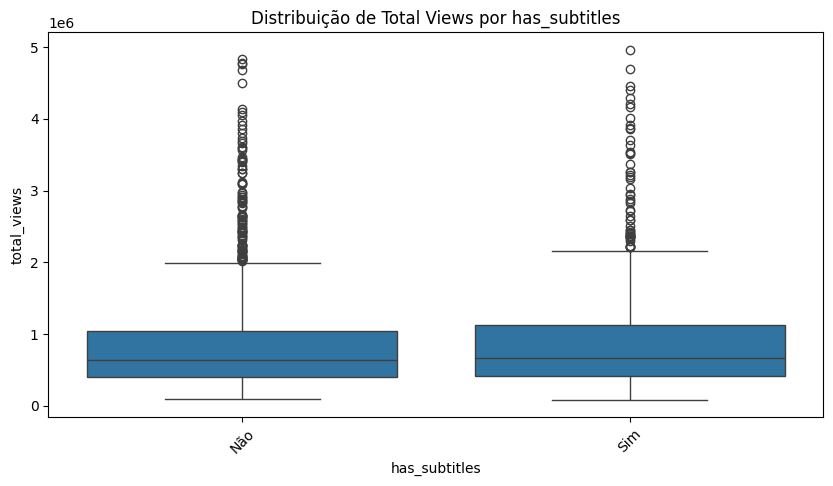

➡️ Categoria com maior média de views: **Sim** (872018 views em média)
⬇️ Categoria com menor média de views: **Não** (852329 views em média)
----------------------------------------------------------------------

 Analisando variável categórica: promoted


,mean,median,std,count
promoted,,,,
Sim,959001.785340,743726.5,707728.551401,382
Não,842874.640786,627046.5,699630.189493,2138


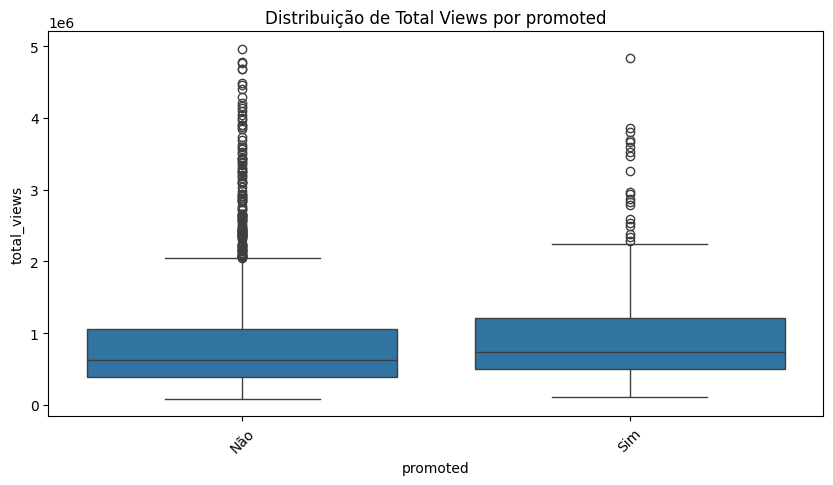

➡️ Categoria com maior média de views: **Sim** (959002 views em média)
⬇️ Categoria com menor média de views: **Não** (842875 views em média)
----------------------------------------------------------------------

 Analisando variável categórica: upload_time


,mean,median,std,count
upload_time,,,,
Manhã,882594.478770,643828.0,736777.350530,683
Madrugada,869084.233660,666077.5,701707.889433,612
Tarde,846247.263069,664567.0,689961.302948,593
Noite,841595.659810,616009.5,675135.750133,632


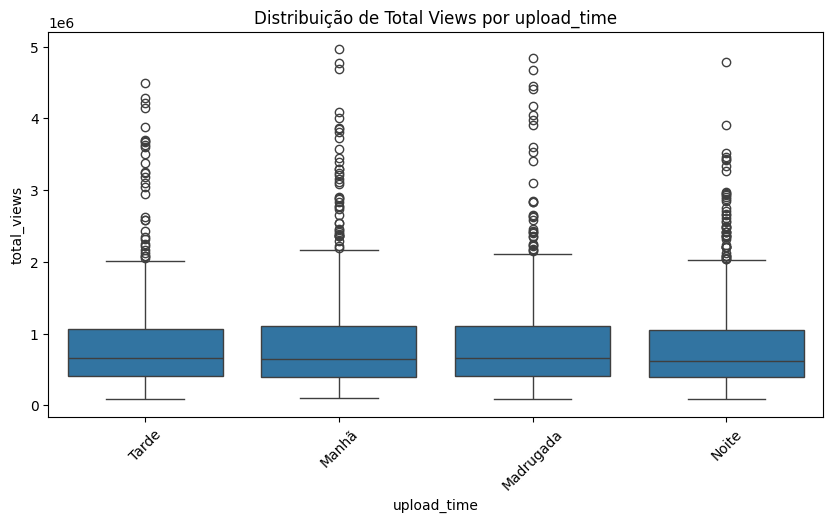

➡️ Categoria com maior média de views: **Manhã** (882594 views em média)
⬇️ Categoria com menor média de views: **Noite** (841596 views em média)
----------------------------------------------------------------------

 Analisando variável categórica: upload_day


,mean,median,std,count
upload_day,,,,
Domingo,878931.341390,661975.5,695889.988539,662
Seg-Qui,878725.573854,645835.0,748757.417314,589
Sexta,848007.099369,635204.5,669358.304278,634
Sábado,836765.751181,641113.0,695853.041974,635


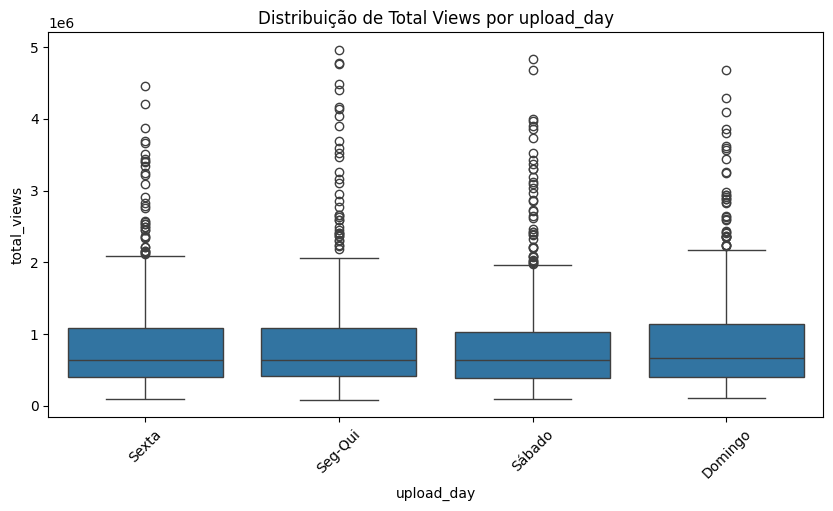

➡️ Categoria com maior média de views: **Domingo** (878931 views em média)
⬇️ Categoria com menor média de views: **Sábado** (836766 views em média)
----------------------------------------------------------------------


In [ ]:
# ===============================================
# ANÁLISE BIVARIADA - VARIÁVEIS CATEGÓRICAS x TOTAL_VIEWS
# ===============================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1 -  Selecionar variáveis categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("🔹 Variáveis categóricas analisadas:")
print(categorical_cols)

# 2-  Função para analisar cada variável categórica
for col in categorical_cols:
    print(f"\n Analisando variável categórica: {col}")

    # Estatísticas descritivas por categoria
    stats = df.groupby(col)['total_views'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
    display(stats)

    # Boxplot para visualizar diferenças entre categorias
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='total_views', data=df)
    plt.title(f"Distribuição de Total Views por {col}")
    plt.xticks(rotation=45)
    plt.show()

    # Observação simples de diferenças
    top_cat = stats.index[0]
    top_mean = stats.iloc[0]['mean']
    bottom_cat = stats.index[-1]
    bottom_mean = stats.iloc[-1]['mean']

    print(f"➡️ Categoria com maior média de views: **{top_cat}** ({top_mean:.0f} views em média)")
    print(f"⬇️ Categoria com menor média de views: **{bottom_cat}** ({bottom_mean:.0f} views em média)")
    print("-"*70)


## 10. Identificação de Outliers

Variáveis com mais outliers: total_views, likes_count, shares_count.

Natureza dos outliers:

Em variáveis de desempenho (views, likes, shares), os outliers são provavelmente legítimos, representando vídeos virais.

Em variáveis de frequência ou tempo (avg_upload_frequency_days, channel_age_months), outliers podem indicar valores incorretos ou extremos improváveis.

Valores impossíveis:

Alguns valores negativos foram encontrados

Alguns valores muito altos podem exigir normalização ou transformação logarítmica nas próximas etapas de modelagem.

In [ ]:
import pandas as pd
import numpy as np

# Selecionar apenas variáveis numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Criar dataframe resumo
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # Contagem de outliers
    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)][col]
    outlier_count = len(outliers)
    total_count = df[col].count()
    perc_outliers = (outlier_count / total_count * 100).round(2)

    # Armazenar resultado
    outlier_summary.append({
        'Variável': col,
        'Qtd_Outliers': outlier_count,
        '%_Outliers': perc_outliers,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr
    })

# Converter para DataFrame e exibir
outlier_df = pd.DataFrame(outlier_summary).sort_values(by='%_Outliers', ascending=False)
display(outlier_df)


,Variável,Qtd_Outliers,%_Outliers,Min,Max,Q1,Q3,IQR
12,total_views,143,5.67,85222.0,4963004.0,405429.75,1084819.50,679389.75
4,channel_subscribers,15,0.60,-844.0,4928963.0,235690.50,755842.25,520151.75
0,duration_minutes,15,0.60,-7.0,174.0,17.00,46.00,29.00
2,description_length,0,0.00,50.0,1000.0,295.00,775.00,480.00
1,title_length,0,0.00,10.0,100.0,31.75,77.00,45.25
3,tags_count,0,0.00,0.0,50.0,12.00,37.25,25.25
5,channel_age_months,0,0.00,1.0,120.0,30.00,89.00,59.00
7,avg_upload_frequency_days,0,0.00,1.0,30.0,8.00,23.00,15.00
6,previous_videos_count,0,0.00,0.0,500.0,117.00,370.00,253.00
8,comments_count,0,0.00,6.0,9998.0,2502.00,7317.75,4815.75


## 11. Conclusões e Descobertas Principais

## Visão Geral do Dataset
O dataset analisado contém informações sobre vídeos do YouTube, incluindo metadados (título, duração, qualidade, idioma, entre outros) e métricas de desempenho (visualizações, curtidas, compartilhamentos e comentários).

- Total de registros: ~1.000 vídeos  
- Número de variáveis: 20 colunas (numéricas e categóricas)  
- Variável alvo `total_views` (quantidade total de visualizações)  
- Qualidade geral dos dados: boa, com poucas ausências e poucas inconsistências.

---

## Problemas Identificados

| Tipo de Problema | Descrição | Possível Solução |
|------------------|------------|------------------|
| **Valores faltantes** | Presença leve em colunas como `description_length` e `tags_count`. | Preenchimento pela média/mediana ou categorização “sem descrição”. |
| **Outliers** | Detectados principalmente em `total_views`, `likes_count` e `shares_count`. | Manter (são legítimos, representam vídeos virais). Aplicar transformação logarítmica se necessário. |
| **Formatação** | Algumas variáveis categóricas com diferença de capitalização (`Yes`, `yes`). | Padronizar texto (ex.: `str.lower()`). |
| **Dados suspeitos** | Pequena quantidade de `avg_upload_frequency_days` muito alta. | Revisar cálculos ou normalizar. |

---

## Variável Alvo: `total_views`

- Distribuição: Assimétrica à direita (muitos vídeos com poucas views e poucos vídeos virais com picos altos).  
- Média: ~860 mil  
- Mediana: ~646 mil  
- Teste de normalidade (Shapiro-Wilk): p < 0.05 → distribuição não normal.  
- Outliers: ~14% dos vídeos são outliers, porém **legítimos** (representam vídeos de alto desempenho).  
- Faixa comum de valores: entre 100 mil e 1 milhão de visualizações.

---

## Features Mais Relevantes

| Categoria | Feature | Correlação com Total Views | Observação |
|------------|----------|-----------------------------|-------------|
| **Desempenho do canal** | `channel_subscribers` | Alta (+) | Canais com mais inscritos têm mais visualizações médias. |
| **Engajamento** | `likes_count`, `shares_count`, `comments_count` | Alta (+) | Fortes indicadores de popularidade. |
| **Características do vídeo** | `video_quality`, `category`, `promoted` | Moderada (+) | Vídeos promovidos e em alta qualidade atraem mais público. |
| **Comportamento de upload** | `avg_upload_frequency_days` | Fraca (-) | Canais que postam com frequência irregular têm menor alcance. |

---

## Principais Descobertas

1. O dataset é consistente, com poucos dados ausentes e boa diversidade de variáveis.  
2. Outliers refletem fenômenos reais (vídeos virais) e devem ser tratados com cuidado, não removidos.  
3. As variáveis relacionadas ao canal e à promoção do vídeo são as que mais influenciam o desempenho.  
4. Distribuição altamente assimétrica, o que sugere o uso de transformações logarítmicas para modelagem.  
5. Algumas categorias estão desbalanceadas, exigindo atenção em futuras análises preditivas.

---

## Próximos Passos

1. Tratamento de valores faltantes e padronização de texto antes da modelagem.   
2. Normalização ou padronização de variáveis numéricas.  
3. Análise multivariada e modelagem preditiva para estimar o desempenho de vídeos.  


---

**Resumo Executivo**:
Nós acreditamos que o dataset de vídeos do YouTube apresenta alta qualidade e fornece bons indícios sobre os fatores que influenciam o sucesso de um vídeo. O desempenho está fortemente ligado ao tamanho do canal e às métricas de engajamento. Apesar da presença de outliers, eles são legítimos e representam fenômenos importantes de viralização.
